# Activity 5.2 Topic Modeling

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 313
Code Title: | Advanced Machine Learning and Deep Learning
2nd Semester | AY 2025-2026
<u>**Hands-on Activity 8.2** | **Topic Modeling**
**Name** | Adrian Justin Bulambao
**Section** | CPE32S3
**Date Performed**: | March 26, 2026
**Date Submitted**: | March 26, 2026
**Instructor**: | Engr. Neal Barton James Matira


#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset. 
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [1]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets

categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train', 
                                       categories=categories, 
                                       remove=('headers', 
                                               'footers', 'quotes'))

In [2]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),  
                                   stop_words='english', 
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [4]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

In [5]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [6]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
        
display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


* Open a new dataset from dap_split.txt 
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [ ]:
with open('ap.txt','r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

In [ ]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

In [9]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques. 

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),  
                                   stop_words='english', 
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [11]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [12]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20)


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [13]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

# Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

### Importing the dataset

In [14]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

wine = pd.read_csv(
    'winereviews-tapi.csv',
    sep='|', # the file contents is separated by "|" so using this to fix  
)

wine.head(1)

,doc_key,doc_title,doc_label,doc_province,doc_points,doc_price,doc_content,doc_original,doc_variety,doc_taster,doc_place
0,86023,Lange 2011 Three Hills Cuvée Pinot Noir (Willamette Valley) Three Hills Cuvée (Pinot Noir) by Paul Gregutt,US,Oregon,88,40.0,"A tart, astringent Pinot, it needs a bit more time in bottle to flesh out further. Tart red fruits are accented with muted herbal elements and just a light touch of barrel toast.","A tart, astringent Pinot, it needs a bit more time in bottle to flesh out further. Tart red fruits are accented with muted herbal elements and just a light touch of barrel toast.",Pinot Noir,Paul Gregutt,US Oregon Willamette Valley Willamette Valley


### Preprocessing Wine Reviews Dataset

checking for null values

In [15]:
wine.isna().sum()

doc_key            0
doc_title          0
doc_label          7
doc_province       7
doc_points         0
doc_price        699
doc_content        0
doc_original       0
doc_variety        0
doc_taster      2055
doc_place          0
dtype: int64

- The dataset contains some empty values in certain columns.  
- The column we will be using the **`doc_original`**, which contains the original human-written reviews.  
- We won’t be needing the other columns for text analysis at this stage.
- However, we won’t drop any rows, even if some columns are empty, because we only need `doc_original` for preprocessing.

In [16]:
pd.set_option('display.max_rows', None)
wine['doc_variety'].value_counts()

doc_variety
Pinot Noir                             1090
Chardonnay                              921
Red Blend                               697
Cabernet Sauvignon                      683
Bordeaux-style Red Blend                506
Riesling                                401
Sauvignon Blanc                         388
Syrah                                   354
Rosé                                    243
Merlot                                  226
Zinfandel                               226
Malbec                                  223
Sangiovese                              205
Nebbiolo                                194
Sparkling Blend                         187
Portuguese Red                          176
White Blend                             173
Tempranillo                             144
Pinot Gris                              123
Cabernet Franc                          109
Grüner Veltliner                        107
Rhône-style Red Blend                   100
Bordeaux-style White

there are 346 labels in the dataset, it will be hard and time consuming doing all of it so I will drop those that are less than 300

In [17]:
variety_counts = wine['doc_variety'].value_counts()
valid_varieties = variety_counts[variety_counts >= 300].index
wine_filtered = wine[wine['doc_variety'].isin(valid_varieties)]
wine_filtered['doc_variety'].value_counts()

doc_variety
Pinot Noir                  1090
Chardonnay                   921
Red Blend                    697
Cabernet Sauvignon           683
Bordeaux-style Red Blend     506
Riesling                     401
Sauvignon Blanc              388
Syrah                        354
Name: count, dtype: int64

In [18]:
wine_order = [
    "Pinot Noir",
    "Chardonnay",
    "Red Blend",
    "Cabernet Sauvignon",
    "Bordeaux-style Red Blend",
    "Riesling",
    "Sauvignon Blanc",
    "Syrah"
]

# Create a mapping dictionary
wine_map = {wine: idx for idx, wine in enumerate(wine_order)}

# Map the values in the filtered dataframe
wine_filtered['wine_label'] = wine_filtered['doc_variety'].map(wine_map)

# Check the result
wine_filtered[['doc_variety', 'wine_label']].head(10)

,doc_variety,wine_label
0,Pinot Noir,0
1,Red Blend,2
2,Cabernet Sauvignon,3
5,Bordeaux-style Red Blend,4
11,Pinot Noir,0
13,Cabernet Sauvignon,3
15,Pinot Noir,0
17,Bordeaux-style Red Blend,4
18,Red Blend,2
21,Pinot Noir,0


there are now only 8 classes from the 346

In [19]:
document = wine_filtered['doc_original']

In [20]:
import re

newline = lambda x: re.sub('\n', ' ', x)
alphanumeric = lambda x: re.sub('\w*\d\w*', ' ', x)

corpus = document.map(newline).map(alphanumeric)
corpus.head()

<>:4: SyntaxWarning: invalid escape sequence '\w'
<>:4: SyntaxWarning: invalid escape sequence '\w'
C:\Users\JUSTIN\AppData\Local\Temp\ipykernel_20628\3033546233.py:4: SyntaxWarning: invalid escape sequence '\w'
  alphanumeric = lambda x: re.sub('\w*\d\w*', ' ', x)


0                                                                                    A tart, astringent Pinot, it needs a bit more time in bottle to flesh out further. Tart red fruits are accented with muted herbal elements and just a light touch of barrel toast.
1                                                                                                    The cola and licorice aromas are candied and easygoing. This feels acidic and snappy, with red cherry and berry flavors that end with a crisp, sheer, rugged feel.
2     A good value, this starts off a little shaky thanks to some barnyard scents on the nose, then rights itself. Herbal-tobacco notes accent plum-prune flavors in this medium-bodied wine with a creamy-smooth texture. Soft and easygoing, it's ideal to drink now.
5                                                                                                                                                                                    -  Soft, ripe, smooth, with

performing lemmatization

In [21]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# 1. Download required NLTK data (You only need to run this cell once)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JUSTIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\JUSTIN\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JUSTIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JUSTIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\JUSTIN\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\JUSTIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-dat

True

In [22]:
# Map POS tag to WordNet POS for accurate lemmatization
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

In [23]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text.lower())          # tokenize and lowercase
    pos_tags = pos_tag(words)                    # get part-of-speech
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) 
                        for word, pos in pos_tags]
    return " ".join(lemmatized_words)

In [24]:
corpus_lemmatized = document.map(lambda x: lemmatize_text(str(x)))

corpus_lemmatized.head()

0                                                                                            a tart , astringent pinot , it need a bit more time in bottle to flesh out far . tart red fruit be accent with muted herbal element and just a light touch of barrel toast .
1                                                                                                      the cola and licorice aroma be candy and easygoing . this feels acidic and snappy , with red cherry and berry flavor that end with a crisp , sheer , rugged feel .
2     a good value , this start off a little shaky thanks to some barnyard scent on the nose , then right itself . herbal-tobacco note accent plum-prune flavor in this medium-bodied wine with a creamy-smooth texture . soft and easygoing , it 's ideal to drink now .
5                                                                                                                                                                               88-90 soft , ripe , smooth

In [25]:
count_vectorizer = CountVectorizer(ngram_range=(1, 2),  
                                   stop_words='english', 
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(corpus_lemmatized)

In [26]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 8
n_iter = 25
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00297793, 0.00297687, 0.00297816, 0.00297716, 0.00297669,
       0.00297689, 0.9791601 , 0.00297619])

from the result, it can be seen that it could belong to topic 8 as it has the highest score.

In [27]:
print(corpus[0])

A tart, astringent Pinot, it needs a bit more time in bottle to flesh out further. Tart red fruits are accented with muted herbal elements and just a light touch of barrel toast.


In [28]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic", ix+1)
        print(" ".join([feature_names[i] 
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print("-"*60)  # separator for readability

# Display top 20 words/phrases per topic
display_topics(lda, count_vectorizer.get_feature_names_out(), 20)

Topic 1
flavor finish apple lemon palate acidity lime note citrus peach chardonnay aroma pear dry nose green crisp pineapple fruit orange
------------------------------------------------------------
Topic 2
cabernet blend sauvignon blackberry cabernet sauvignon merlot flavor tannin chocolate black wine cherry dark syrah currant oak franc fruit cassis aroma
------------------------------------------------------------
Topic 3
palate black aroma cherry flavor finish nose plum spice pepper note fruit tannin red black cherry offer berry wine herb raspberry
------------------------------------------------------------
Topic 4
berry herbal sugar quickly finish floor tomato forest floor berry flavor brown feel brown sugar residual berry fruit forest cherry berry bit fade residual sugar taste
------------------------------------------------------------
Topic 5
medium medium bodied bodied value bodied wine bit herbal producer finish swirl nose start plummy mix glass stemmy touch rhubarb quality m

Adding the wine variety now

In [29]:
topic_names = [
    "Pinot Noir",
    "Chardonnay",
    "Red Blend",
    "Cabernet Sauvignon",
    "Bordeaux-style Red Blend",
    "Riesling",
    "Sauvignon Blanc",
    "Syrah"
]

In [30]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        name = topic_names[ix] if topic_names else f"Topic {ix+1}"
        print(name)
        print(" ".join([feature_names[i] 
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print("-"*120)        

In [31]:
display_topics(lda, count_vectorizer.get_feature_names_out(), 20, topic_names=topic_names)

Pinot Noir
flavor finish apple lemon palate acidity lime note citrus peach chardonnay aroma pear dry nose green crisp pineapple fruit orange
------------------------------------------------------------------------------------------------------------------------
Chardonnay
cabernet blend sauvignon blackberry cabernet sauvignon merlot flavor tannin chocolate black wine cherry dark syrah currant oak franc fruit cassis aroma
------------------------------------------------------------------------------------------------------------------------
Red Blend
palate black aroma cherry flavor finish nose plum spice pepper note fruit tannin red black cherry offer berry wine herb raspberry
------------------------------------------------------------------------------------------------------------------------
Cabernet Sauvignon
berry herbal sugar quickly finish floor tomato forest floor berry flavor brown feel brown sugar residual berry fruit forest cherry berry bit fade residual sugar taste
-------

* Additional instructions for Supplementary Evaluation
* Show at least 2 examples of datapoints for each topic
* (Optional) Plot the clustering of topics using TruncatedSVD, KMeans, TSNE using a Scatter Plot

In [32]:
dominant_wine = np.argmax(data, axis=1)
wine_filtered['dominant_wine'] = dominant_wine

In [34]:
n_examples = 2

for topic in range(lda.n_components):  # loop through all topics
    print(f"Topic {topic+1} ({topic_names[topic]}):")
    examples = wine_filtered[wine_filtered['dominant_wine'] == topic]['doc_original'].head(n_examples)
    for i, ex in enumerate(examples, 1):
        print(f"Example {i}: {ex}\n")
    print("-"*200)

Topic 1 (Pinot Noir):
Example 1: This is a light, delicately crafted and affordable offering of the variety, a good value for the quality, that delivers nuanced layers of raspberry, strawberry and rose petal.

Example 2: There's a lack of balance, with thin, slightly bitter fruit overriding any complexity that may have been achieved with more oak. This is not offensive, it just lacks character.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Topic 2 (Chardonnay):
Example 1: One in a series of small cuvées from the Right and Left banks, this pure Cabernet Sauvignon (from the great 2010 vintage) is still young. It does have impressively concentrated fruit and powerful tannins to allow it to develop well. Drink this impressive wine from 2019.

Example 2: The highly anticipated best barrel blend from this pioneering Syrah producer offers 

In [42]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
data_2d = svd.fit_transform(data)

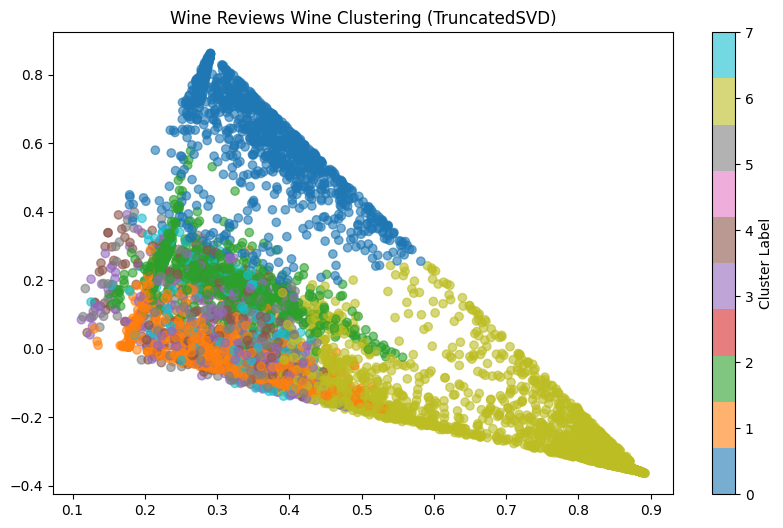

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(data_2d[:,0], data_2d[:,1], c=dominant_wine, cmap='tab10', alpha=0.6)
plt.colorbar(label='Cluster Label')
plt.title('Wine Reviews Wine Clustering (TruncatedSVD)')
plt.show()

Analysis: The Truncated SVD plot shows that most points are close to each other, indicating the topics are not well-separated and have high similarity, with only a small spread giving it a prism-like appearance.

In [107]:
from sklearn.manifold import TSNE

# Reduce LDA topic distribution to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=300)
data_tsne = tsne.fit_transform(data)

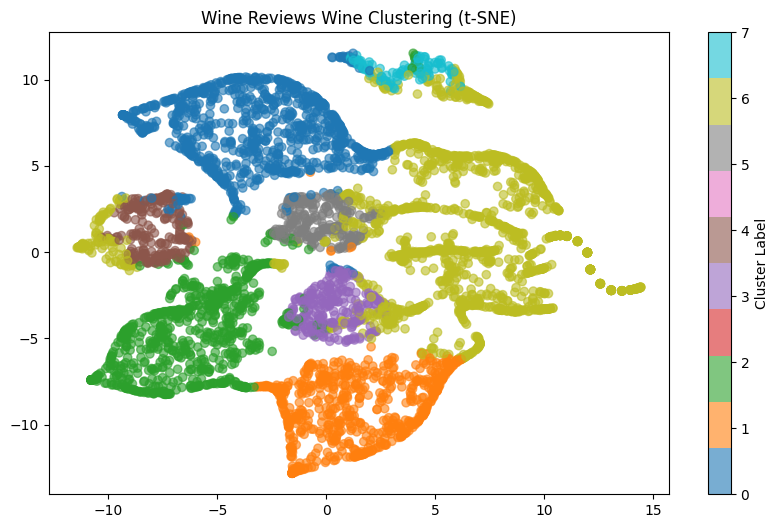

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(data_tsne[:,0], data_tsne[:,1], c=dominant_wine, cmap='tab10', alpha=0.6)
plt.colorbar(label='Cluster Label')
plt.title('Wine Reviews Wine Clustering (t-SNE)')
plt.show()

Analysis: The t-SNE plot looks like a fish or stingray of some sort, showing that the topics aren’t clearly separated and it overlaps with one another.

## Supervised

### using count vectorizer

unigram only

In [93]:
from sklearn.model_selection import train_test_split

X = wine_filtered['doc_original']

y = wine_filtered['doc_variety']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

In [94]:
print(f'shape x_train: {X_train.shape}')
print(f'shape x_test: {X_test.shape}')
print(f'shape y_train: {y_train.shape}')
print(f'shape y_test: {y_test.shape}')

shape x_train: (4032,)
shape x_test: (1008,)
shape y_train: (4032,)
shape y_test: (1008,)


In [95]:
cv1 = CountVectorizer()

X_train_cv1 = cv1.fit_transform(X_train)
X_test_cv1  = cv1.transform(X_test)

print(X_train_cv1.toarray().shape)

(4032, 7863)


In [96]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=600, 
                            random_state=42, 
                            n_jobs=-1)

# Train the model
rf.fit(X_train_cv1, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

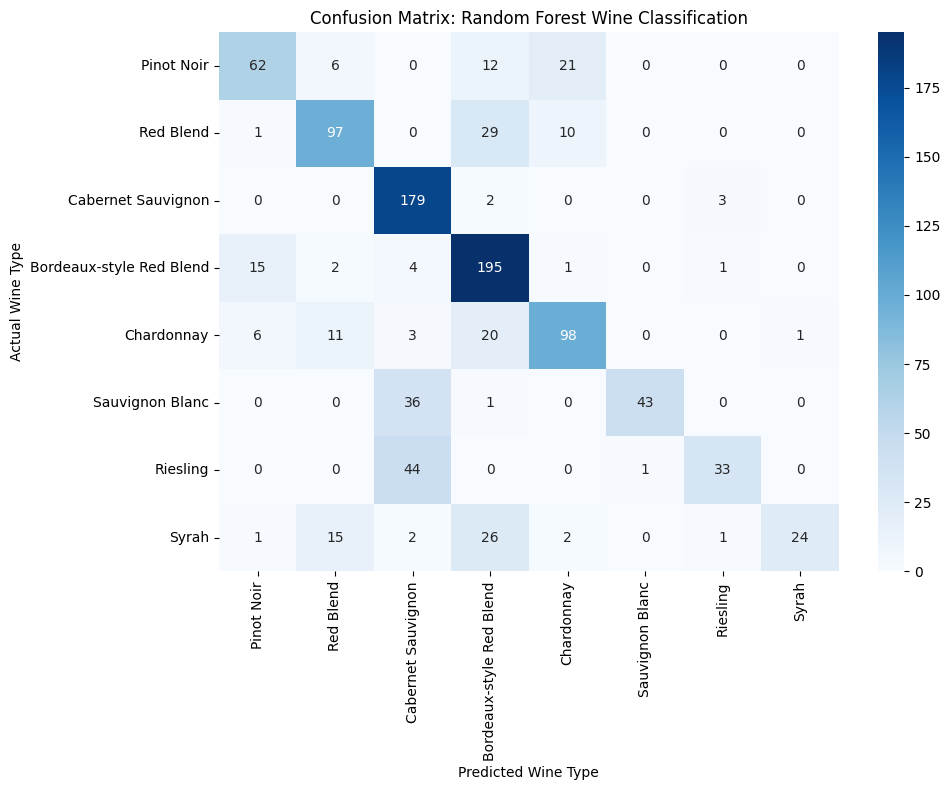

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on test set
y_pred = rf.predict(X_test_cv1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine_filtered['doc_variety'].unique(),
            yticklabels=wine_filtered['doc_variety'].unique())
plt.xlabel('Predicted Wine Type')
plt.ylabel('Actual Wine Type')
plt.title('Confusion Matrix: Random Forest Wine Classification')
plt.show()

In [98]:
report = classification_report(y_test, y_pred, target_names=wine_filtered['doc_variety'].unique())
print(report)

                          precision    recall  f1-score   support

              Pinot Noir       0.73      0.61      0.67       101
               Red Blend       0.74      0.71      0.72       137
      Cabernet Sauvignon       0.67      0.97      0.79       184
Bordeaux-style Red Blend       0.68      0.89      0.78       218
              Chardonnay       0.74      0.71      0.72       139
         Sauvignon Blanc       0.98      0.54      0.69        80
                Riesling       0.87      0.42      0.57        78
                   Syrah       0.96      0.34      0.50        71

                accuracy                           0.73      1008
               macro avg       0.80      0.65      0.68      1008
            weighted avg       0.76      0.73      0.71      1008



unigram and bigram

In [111]:
cv2 = CountVectorizer(ngram_range=(1,2), binary=True)

X_train_cv2 = cv2.fit_transform(X_train)
X_test_cv2  = cv2.transform(X_test)

print(X_train_cv2.toarray().shape)

(4032, 70025)


In [112]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_cv2,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

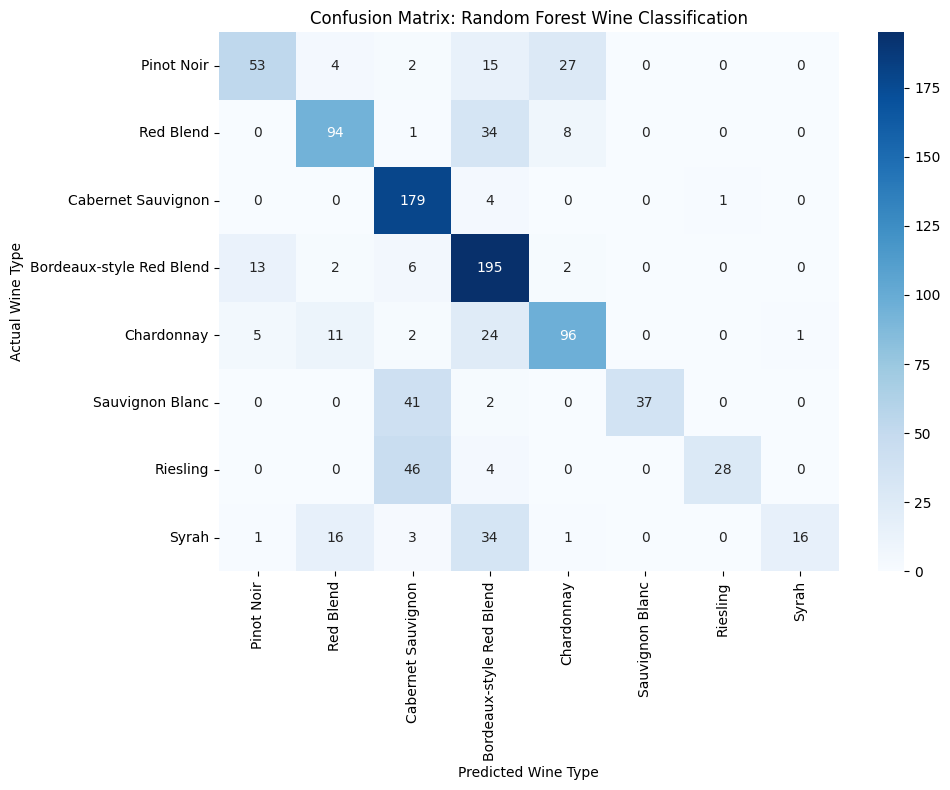

In [113]:
y_pred = rf.predict(X_test_cv2)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine_filtered['doc_variety'].unique(),
            yticklabels=wine_filtered['doc_variety'].unique())
plt.xlabel('Predicted Wine Type')
plt.ylabel('Actual Wine Type')
plt.title('Confusion Matrix: Random Forest Wine Classification')
plt.show()

In [114]:
report = classification_report(y_test, y_pred, target_names=wine_filtered['doc_variety'].unique())
print(report)

                          precision    recall  f1-score   support

              Pinot Noir       0.74      0.52      0.61       101
               Red Blend       0.74      0.69      0.71       137
      Cabernet Sauvignon       0.64      0.97      0.77       184
Bordeaux-style Red Blend       0.62      0.89      0.74       218
              Chardonnay       0.72      0.69      0.70       139
         Sauvignon Blanc       1.00      0.46      0.63        80
                Riesling       0.97      0.36      0.52        78
                   Syrah       0.94      0.23      0.36        71

                accuracy                           0.69      1008
               macro avg       0.80      0.60      0.63      1008
            weighted avg       0.75      0.69      0.67      1008



### Using Tf-id

In [99]:
X = wine_filtered['doc_original']
y = wine_filtered['doc_variety']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',   
    max_df=0.6,            
    ngram_range=(1,2)       
)

In [102]:

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)


print(X_train_tfidf.shape, X_test_tfidf.shape)

(4032, 67516) (1008, 67516)


In [103]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=600,  
    random_state=42,  
    n_jobs=-1        
)

# Train the model
rf.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

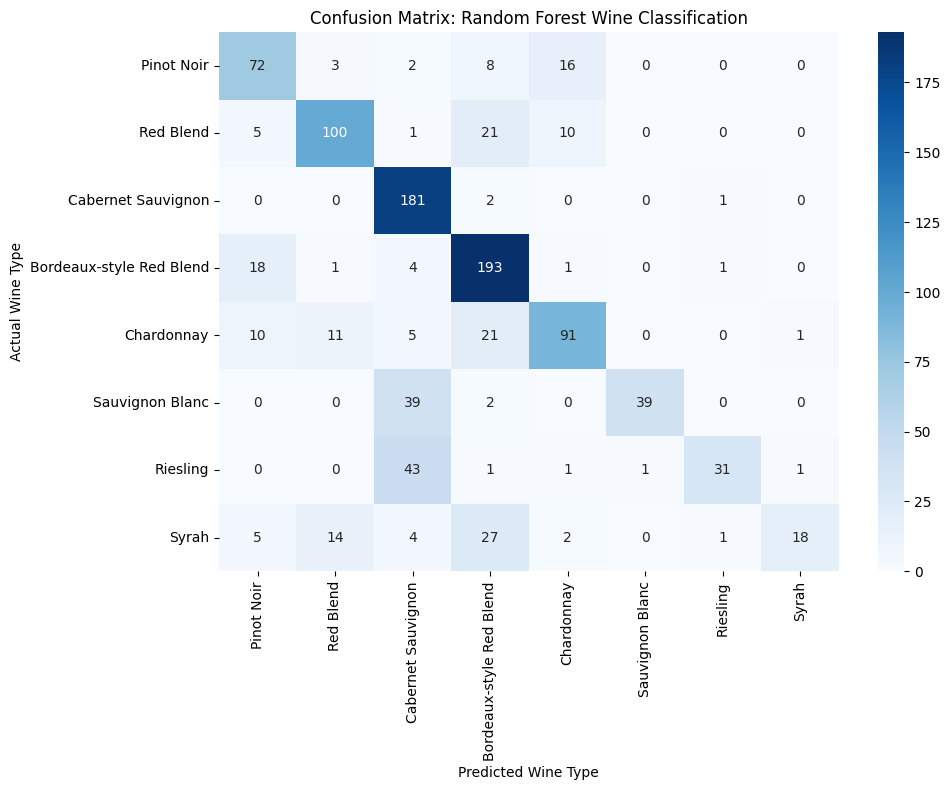

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on test set
y_pred = rf.predict(X_test_tfidf)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine_filtered['doc_variety'].unique(),
            yticklabels=wine_filtered['doc_variety'].unique())
plt.xlabel('Predicted Wine Type')
plt.ylabel('Actual Wine Type')
plt.title('Confusion Matrix: Random Forest Wine Classification')
plt.show()

In [105]:
report = classification_report(y_test, y_pred, target_names=wine_filtered['doc_variety'].unique())
print(report)

                          precision    recall  f1-score   support

              Pinot Noir       0.65      0.71      0.68       101
               Red Blend       0.78      0.73      0.75       137
      Cabernet Sauvignon       0.65      0.98      0.78       184
Bordeaux-style Red Blend       0.70      0.89      0.78       218
              Chardonnay       0.75      0.65      0.70       139
         Sauvignon Blanc       0.97      0.49      0.65        80
                Riesling       0.91      0.40      0.55        78
                   Syrah       0.90      0.25      0.40        71

                accuracy                           0.72      1008
               macro avg       0.79      0.64      0.66      1008
            weighted avg       0.76      0.72      0.70      1008



## Conclusion

From this activity, I learned how to work with real-world text data by preprocessing wine reviews, extracting those wine varieties using LDA, and visualizing them with techniques like TruncatedSVD and t-SNE. I also tried supervised learning and performing Random Forest classifier to predict wine varieties from the reviews, achieving 69-72% and 73% accuracy from count vector and tf, which highlighted how some varieties share similar descriptions. Overall, this activity helped me understand text preprocessing, topic modeling, dimensionality reduction, and supervised classification, and how these techniques can be combined to analyze and make predictions from textual data. I also want to learn how to do better at this.